In [13]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio      # βιβιοθήκη για να "παίζουμε" ήχους (μεταξύ άλλων)

## Άσκηση - Ψηφιακά εφέ ήχου
i. Θεωρήστε την παρακάτω εξίσωση διαφορών που περιγράφει ένα αιτιατό ΓΧΑ σύστημα
$$y[n] = x[n] + \alpha x[n-M], \: \: |a| < 1 \ \  (1)$$

(α')Υπολογίστε στο χαρτί σας τη συνάρτηση μεταφοράς, $H(z)$, του παραπάνω συστήματος. 

<u>**Απάντηση**</u>

Θα είναι:

$$y[n] = x[n] + \alpha x[n-M] \overset{Z}{\longleftrightarrow} Y(z) = X(z) + \alpha X(z)z^{-M} \Rightarrow Y(z) = X(z)(1 + \alpha z^{-M})$$

και άρα

$$H_{1}(z) = \frac{Y(z)}{X(z)} = 1 + \alpha z^{-M} = \frac{z^{M} + \alpha}{z^{M}}$$

δηλαδή η συνάρτηση μεταφοράς έχει πόλο πολλαπλότητας $M$ στο σημείο $z = 0$. Για να είναι το σύστημα αιτιατό, πρέπει $ROC_{H_{1}}: |z| > 0$.  Έτσι, προκύπτει ότι

$$H_{1}(z) = 1 + \alpha z^{-M}, \: |z|>0$$

(β') Βρείτε στο χαρτί σας την κρουστική απόκριση $h[n]$.

<u>**Απάντηση**</u>

H κρουστική απόκριση είναι ο αντίστροφος μετασχηματισμός Ζ της συνάρτησης μεταφοράς που υπολογίσαμε.
Βάσει της ιδιότητας της γραμμικότητας και του πίνακα γνωστών ζευγών του μετασχηματισμού Ζ, προκύπτει:

$$h_{1}[n] = \delta [n] + \alpha \delta [n - M]$$

(γ') Υπολογίστε στο χαρτί σας την απόκριση σε συχνότητα, $H(e^{j\omega})$. 

<u>**Απάντηση**</u>

Βρήκαμε ότι το πεδίο σύγκλισης της συνάρτησης μεταφοράς $H(z)$ περιέχει τον μοναδιαίο κύκλο, άρα ορίζεται ο μετασχηματισμός Fourier μέσω του μετασχηματισμού $Ζ$. Έτσι, η απόκριση σε συχνότητα του συστήματος υπολογίζεται ως:

$$H_{1}(e^{j\omega}) = H_{1}(z) \Big|_{z = e^{j\omega}} \Rightarrow H_{1}(e^{j\omega}) = 1 + \alpha e^{-j\omega M}$$

(δ') Βρείτε στην Python την απόκριση πλάτους και φάσης, με χρήση της συνάρτησης $[H,W] = freqz(...)$ σε $2048$ σημεία (δείτε το documentation της για να δείτε πως εισάγετε την πληροφορία των σημείων). Χρησιμοποιήστε τις συναρτήσεις ``plt.plot, abs, angle`` κατά τα γνωστά για να κάνετε τις γραφικές παραστάσεις. Θέστε $\alpha = 0.8$ και $M = 3000$.

<u>**Απάντηση**</u>

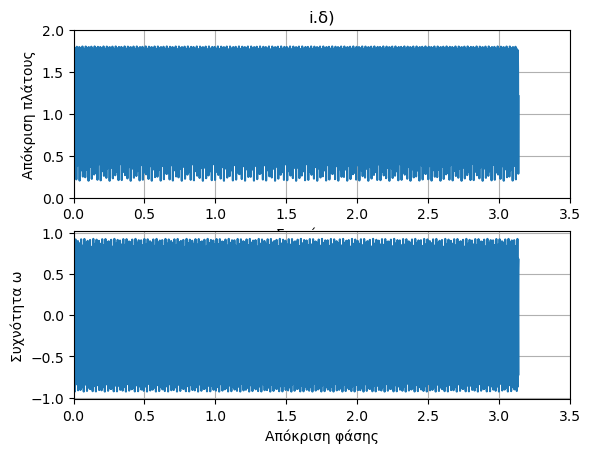

In [14]:
# i.δ)
a = 0.8
M = 3000
n = 2048

den1 = [1]
num1 = np.zeros((1,M-1))[0]
num1[0] = 1
num1[len(num1)-1] = a

W, H = sig.freqz(num1, den1, n)

plt.subplot(2,1,1)
plt.title('i.δ)')
plt.plot(W, abs(H))
plt.xlim(0.0, 3.5)
plt.ylim(0, 2)
plt.grid(True)
plt.ylabel('Απόκριση πλάτους')
plt.xlabel('Συχνότητα ω')

plt.subplot(2,1,2)
plt.plot(W, np.angle(H))
plt.xlim(0.0, 3.5)
plt.grid(True)
plt.xlabel('Απόκριση φάσης')
plt.ylabel('Συχνότητα ω')

plt.show()

ii. Θεωρήστε την παρακάτω εξίσωση διαφορών που περιγράφει ένα αιτιατό ΓΧΑ σύστημα:
$$y[n] + \alpha y[n-M] = x[n], \: \: |a| < 1$$

(α') Υπολογίστε στο χαρτί σας τη συνάρτηση μεταφοράς, $H(z)$, του παραπάνω συστήματος. 

<u>**Απάντηση**</u>

Θα είναι:

$$y[n] + \alpha y[n-M] = x[n] \overset{Z}\longleftrightarrow Y(z) + \alpha Y(z) z^{-M} = X(z) \Rightarrow Y(z)(1 + \alpha z^{-M}) = X(z)$$

και άρα

$$H_{2}(z) = \frac{Y(z)}{X(z)} = \frac{1}{1 + \alpha z^{-M}}$$

με πόλο στο σημείο $z_{1}$ , όπου

$$1 + \alpha z_{1}^{-M} = 0 \Rightarrow z_{1}^{-M} = -\frac{1}{\alpha} = z_{1}^{M} = - \alpha$$

και, αφού ξέρουμε ότι $|α| < 1$, θα είναι $|z_{1}| < 1$. Έτσι, έχουμε $ROC_{H_{2}} : |z| > |z_{1}|$, αφού το σύστημα είναι αιτιατό. Έτσι, προκύπτει ότι

$$H_{2}(z) = \frac{1}{1 + \alpha z^{-M}}, \: |z|>|z_{1}|$$


(β') Βρείτε στο χαρτί σας την κρουστική απόκριση $h[n]$.

<u>**Απάντηση**</u>

Εφαρμόζουμε τη μέθοδο της μακράς διαίρεσης:

$$\begin{array}{r|l}
1 \quad \quad \quad \: \: \: \quad &\underline{1 + \alpha z^{-1} \quad \quad \quad} \\
\underline{-1 \quad -\alpha z^{-M}} & 1 -\alpha^{2}z^{-2M} + \dots \\
\quad \quad \quad \: \: \: \quad - \alpha z^{-M} & \\
\underline{\alpha^{2} z^{-2M} \quad + \alpha z^{-M}} & \\
\alpha^{2}z^{-2M} \quad \quad \quad \: \: \: \quad & \\
\underline{-\alpha^{3}z^{-3M} -\alpha^{2}z^{-2M} \quad \quad \quad \:} \: \: \quad & \\
-\alpha^{3}z^{-3M} \quad \quad \quad \: \: \: \quad \quad \quad \quad \: \: \: \quad & \\
\dots \quad \quad \quad \: \: \: \quad & \underline{\quad \quad \quad}
\end{array}$$

Έτσι, προκύπτει
$$H_{2}(z) = \frac{1}{1 + \alpha z^{-M}} = 1 - \alpha z^{-M} + a^{2}z^{-2M} - \alpha ^{3} z^{-3M} + ...$$
H κρουστική απόκριση είναι ο αντίστροφος μετασχηματισμός $Ζ$ της συνάρτησης μεταφοράς που υπολογίσαμε.
Βάσει της ιδιότητας της γραμμικότητας και του πίνακα γνωστών ζευγών του μετασχηματισμού $Ζ$, προκύπτει:
$$h[n] = \delta[n] - \alpha \delta[n - M] + \alpha^{2} \delta[n - 2M] - \alpha^{3} \delta[n - 3M] + ... \Longrightarrow h[n] = \sum_{k = 0}^{+ \infty} \alpha^{k} \delta[n - kM](-1)^{k}$$


(γ') Υπολογίστε στο χαρτί σας την απόκριση σε συχνότητα, $H(e^{j\omega})$.

<u>**Απάντηση**</u>

Βρήκαμε ότι το πεδίο σύγκλισης της συνάρτησης μεταφοράς $H(z)$ περιέχει τον μοναδιαίο κύκλο (αφού $ROC_{H_{2}} : |z| > |z_{1}|$ και z_{1} < 1), άρα ορίζεται ο μετασχηματισμός Fourier μέσω του μετασχηματισμού $Ζ$.
Έτσι, η απόκριση σε συχνότητα του συστήματος υπολογίζεται ως:

$$H_{2}(e^{j\omega}) = H_{2}(z) \Big|_{z = e^{j\omega}} \Longrightarrow H_{2}(e^{j\omega}) = \frac{1}{1 + \alpha e^{-j\omega M}}$$

(δ') Βρείτε στην ``Python`` την απόκριση πλάτους και φάσης, με χρήση της συνάρτησης $\texttt{[H,W] = freqz(...)}$ σε $2048$ σημεία (δείτε το documentation της για να δείτε πως εισάγετε την πληροφορία των σημείων). Χρησιμοποιήστε τις συναρτήσεις $\texttt{plt.plot, abs, angle}$ κατά τα γνωστά για να κάνετε τις γραφικές παραστάσεις. Θέστε $\alpha = 0.8$ και $M = 3000$.

<u>**Απάντηση**</u>

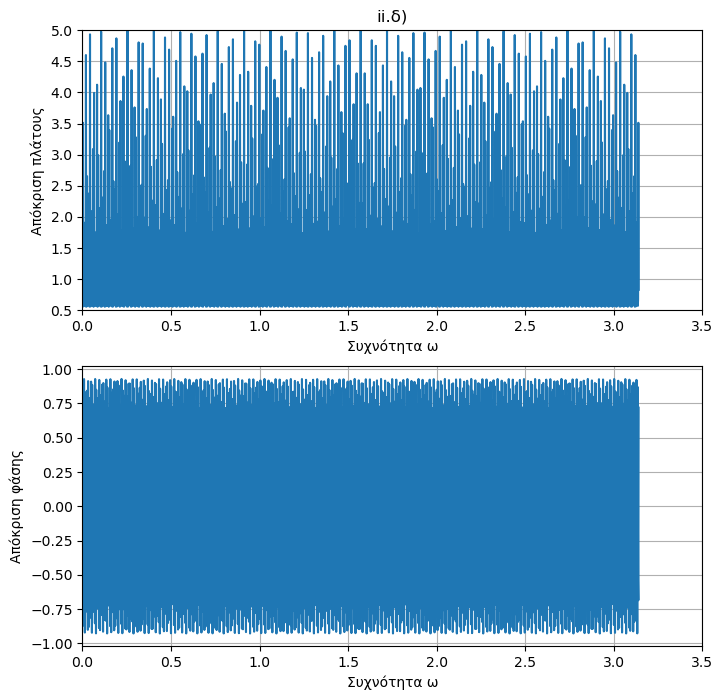

In [15]:
# ii.δ)
a = 0.8
M = 3000
n = 2048

den2 = np.zeros((1, M-1))[0]
den2[0] = 1
den2[len(den2) - 1] = a
num2 = [1]

W, H = sig.freqz(num2, den2, n)

plt.figure(figsize=(8,8))
plt.subplot(2, 1, 1)
plt.title('ii.δ)')
plt.plot(W, abs(H))
plt.grid(True)
plt.ylabel('Απόκριση πλάτους')
plt.xlabel('Συχνότητα ω')
plt.xlim(0.0, 3.5)
plt.ylim(0.5, 5)

plt.subplot(2, 1, 2)
plt.plot(W, np.angle(H))
plt.grid(True)
plt.ylabel('Απόκριση φάσης')
plt.xlabel('Συχνότητα ω')
plt.xlim(0.0, 3.5)

plt.show()

iii. Φιλτράρετε το σήμα $\texttt{furelise.wav}$ που σας δίνεται με καθένα από τα παραπάνω συστήματα. Χρησιμοποιήστε την εντολή $\texttt{filter}$ για αυτό. Οι παράμετροι των εξισώσεων διαφορών θα είναι $\alpha = 0.6$ και $M=3000$. Ακούστε το αποτέλεσμα για κάθε σύστημα. Πώς θα χαρακτηρίζατε την επίδραση των συστημάτων στο σήμα εισόδου, βάσει του αποτελέσματος που ακούτε?

<u>**Απάντηση**</u>

Μετά το φιλτράρισμα του σήματος με παραμέτρους $\alpha = 0.6$, $M = 3000$ για καθένα από τα δύο συστήματα, παρατηρούμε ότι και τα δύο συστήματα προκαλούν παραμόρφωση στο αρχικό σήμα. Συγκεκριμένα, φαίνεται να προστίθεται ηχώ στο σήμα, με αποτέλεσμα να χαλάει η ποιότητα και η εμπειρία ακρόασης. Υπό την επίδραση του 1ου συστήματος, προστίθεται ‘λίγη’ ηχώ. Έτσι, ενώ αυτό γίνεται αντιληπτό, ο ήχος παραμένει σχετικά ευχάριστος. Το 2ο σύστημα όμως προσθέτει σαφώς περισσότερο echo, με αποτέλεσμα η ποιότητα του ήχου να πέφτει δραματικά.

In [19]:
# iii.
fs, s = wavfile.read('./files/furelise.wav')

a = 0.6
M = 3000

# Φιλτράρισμα του furelise.wav χρησιμοποιώντας το πρώτο σύστημα
y1 = sig.lfilter(num1, den1, s)
Audio(y1, rate=fs) 

In [20]:
# Φιλτράρισμα του furelise.wav χρησιμοποιώντας το πρώτο σύστημα
y2 = sig.lfilter(num2, den2, s)
Audio(y2, rate=fs) 

iv. Αποδείξτε στο χαρτί σας ότι τα συστήματα που υλοποιούνται από τις παραπάνω εξισώσεις διαφορών είναι το ένα αντίστροφο του άλλου. Ένα σύστημα $H_{inv}(z)$ ονομάζεται αντίστροφο ενός άλλου, $H(z)$, αν ισχύει:

$$H(z)H_{inv}(z) = 1, \: \: \: R_H \cap R_{H_{inv}} \neq \emptyset \ \ (3)$$

ή εναλλακτικά

$$h[n] * h_{inv}[n] = \delta[n] \ \ (4)$$

<u>**Απάντηση**</u>

Παρατηρούμε ότι:

$$H_{1}(z) H_{2}(z) = (1 + \alpha z^{-M}) \left(\frac{1}{1 + \alpha z^{-M}}\right) = \frac{1 + \alpha z^{-M}}{1 + \alpha z^{-M}} \Longrightarrow H_{1}(z)H_{2}(z) = 1$$

Ακόμα, βρήκαμε ότι $R_{H_{1}} : |z| > 0$ και $R_{H_{2}} : |z| > |z_{1}|$, με $|z_{1}| < 1$. Έτσι,

$$R_{H_{1}} \cap R_{H_{2}} = |z| > |z_{1}| \Longrightarrow R_H \cap R_{H_{inv}} \neq \emptyset$$

Συνεπώς, τα παραπάνω συστήματα είναι αντίστροφα.

v. Αποδείξτε πρακτικά το παραπάνω, περνώντας το σήμα της εξόδου του ενός συστήματος στην είσοδο του άλλου. Ακούστε το τελικό σήμα και το αρχικό σήμα. Είναι τα ίδια? **Σχολιάστε το διαδοχικό φιλτράρισμα**.

<u>**Απάντηση**</u>

Φιλτράροντας το αρχικό σήμα με τα δύο συστήματα σε σειρά, βλέπουμε ότι το τελικό σήμα που προκύπτει ακούγεται ακριβώς ίδιο με το αρχικό σήμα. Έτσι, θα μπορούσαμε να πούμε πρακτικά/εμπειρικά ότι τα συστήματα είναι το ένα αντίστροφο του άλλου.

In [24]:
# Διαδοχική εφαρμογή των δύο συστημάτων στο αρχικό σήμα
y1 = sig.lfilter(num1, den1, s)
Audio(y1, rate=fs)

In [25]:
y = sig.lfilter(num2, den2, y1)
Audio(y, rate=fs)

In [23]:
# Αρχικό σήμα
Audio(s, rate=fs)

---
---